# 1 Import libraries

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl

# 2 Baseline graph

In [3]:
g = nx.Graph()
g.add_edges_from([('a','d'),
                  ('b','e'),
                  ('c','e'),
                  ('d','i'),
                  ('e','i'),
                  ('f','h'),
                  ('g','h'),
                  ('h','i'),('h','j'),
                  ('i','l'),
                  ('j','n'),
                  ('l','m'),('l','n'),('l','k'),('l','o'),
                  ('m','u'),
                  ('n','k'),('n','o'),('n','s'),
                  ('o','k'),('o','p'),('o','s'),
                  ('p','k'),('p','s'),
                  ('k','s'),('k','u'),
                  ('q','s'),
                  ('r','s'),
                  ('s','u')])

for n, d in g.nodes(data=True):
    g.nodes[n]["class"] = g.degree(n)

# 3 Sociopatterns

At the time of writing (July 2021), finding important nodes in a graph has actually taken on a measure of importance that we might not have appreciated before. With the COVID-19 virus spreading, contact tracing has become quite important. In an infectious disease contact network, where individuals are nodes and contact between individuals of some kind are the edges, an "important" node in this contact network would be an individual who was infected who also was in contact with many people during the time that they were infected.

The dataset that we will use in this chapter is the ["sociopatterns network"](http://www.sociopatterns.org/datasets/infectious-sociopatterns-dynamic-contact-networks/) dataset. Incidentally, it's also about infectious diseases.

> This network describes the face-to-face behavior of people during the exhibition INFECTIOUS: STAY AWAY in 2009 at the Science Gallery in Dublin. Nodes represent exhibition visitors; edges represent face-to-face contacts that were active for at least 20 seconds. Multiple edges between two nodes are possible and denote multiple contacts. The network contains the data from the day with the most interactions

To simplify the network, we have represented only the last contact between individuals.



In [5]:
# download the dataset
!gdown https://drive.google.com/uc?id=1REW9CIhtNtdmoO5FrBPeCK5U39p5OMS5

Downloading...
From: https://drive.google.com/uc?id=1REW9CIhtNtdmoO5FrBPeCK5U39p5OMS5
To: /content/out.sociopatterns-infectious
100% 355k/355k [00:00<00:00, 65.4MB/s]


The meaning of the columns in out.sociopatterns-infectious are:

- First column: ID of from node
- Second column: ID of to node
- Third column: edge weight
- Fourth column: timestamp of the edge

In [6]:
# Read the edge list
df = pd.read_csv("out.sociopatterns-infectious",sep=" ",skiprows=2,header=None)
df.head()

,0,1,2,3
0,100,101,1,1247658439
1,100,101,1,1247660019
2,100,102,1,1247658579
3,100,103,1,1247658159
4,100,103,1,1247658179


In [7]:
# lets use only the first three columns
df = df[[0, 1, 2]]
df.columns = ["person1", "person2", "weight"]
df.head()

,person1,person2,weight
0,100,101,1
1,100,101,1
2,100,102,1
3,100,103,1
4,100,103,1


In [8]:
g2 = nx.Graph()

for row in df.iterrows():
  p1 = row[1]["person1"]
  p2 = row[1]["person2"]
  if g2.has_edge(p1, p2):
    g2.edges[p1, p2]["weight"] += 1
  else:
    g2.add_edge(p1, p2, weight=1)

for n in sorted(g2.nodes()):
  g2.nodes[n]["order"] = float(n)

# 4 Core Decomposition

In [13]:
# k-core of the network
# 1-core
# 2-core
# 3-core
set([v for k,v in nx.core_number(g).items()])

{1, 2, 3}

In [14]:
#
# Change the variable core to visualize the nodes in k-core
# Note that 0-core is the all network
core = 3
for i in nx.k_core(g,core):
  print(i)

l
n
k
p
o
s


In [15]:
#
# Change the variable shell to visualize the nodes in k-shell
# Note that vertices in k-shell are member of k-core, however they are not member of (k+1)-core
shell = 3
for i in nx.k_shell(g,shell):
  print(i)

l
n
k
p
o
s


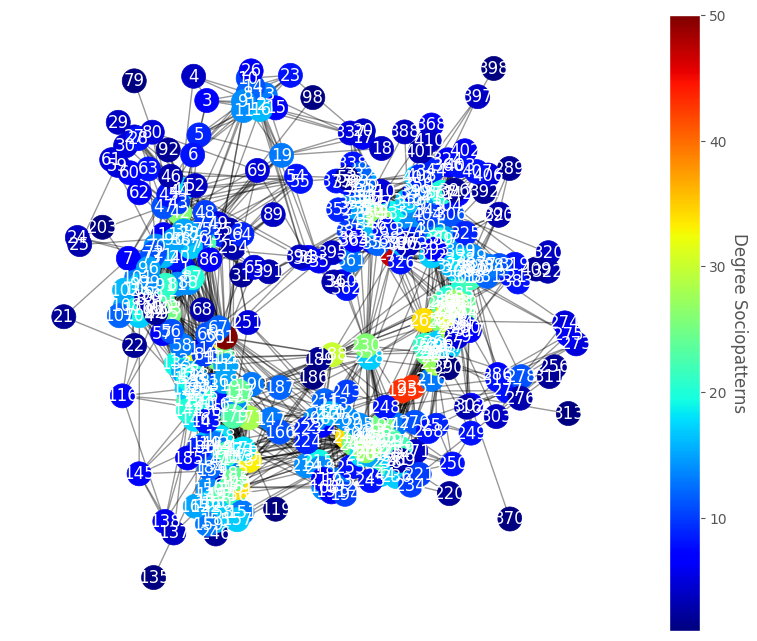

In [16]:
# the degree of network(g2)
fig, ax = plt.subplots(1,1,figsize=(10,8))

# layout position
pos = nx.spring_layout(g2,seed=123456789,k=0.3)
# color of nodes
color = list(dict(nx.degree(g2)).values())

# draw edges
nx.draw_networkx_edges(g2,
                       pos=pos,
                       alpha=0.4, ax=ax)

# draw nodes
nodes = nx.draw_networkx_nodes(g2,
                 pos=pos,
                 node_color=color,
                 cmap=plt.cm.jet,ax=ax)

# draw labels
nx.draw_networkx_labels(g2, pos=pos,
                        font_color='white', ax=ax)

# Criando um ScalarMappable para a colorbar
sm = mpl.cm.ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=min(color), vmax=max(color)))
sm.set_array([])  # Necessário para evitar erros com o ScalarMappable

# Adicionando a barra de cores
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Degree Sociopatterns', rotation=270, labelpad=15)


plt.axis("off")
plt.savefig('sociopatterns.png', transparent=True,dpi=600)
plt.show()

In [17]:
# How many k-cores does this network have?
set([v for k,v in nx.core_number(g2).items()])

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 17}

In [18]:
# 1-core is composed for all vertices in the network because this network is connected
len([g2.degree(node) for node in list(nx.k_core(g2,1))])

410

In [19]:
# how to calculate shell by hands
a = [node for node in list(nx.k_core(g2,1))]
b = [node for node in list(nx.k_core(g2,2))]
np.setxor1d(a,b)

array([ 79,  98, 119, 135, 186, 203, 313, 370, 390, 398])

In [20]:
# who are in the innermost core
print(list(nx.k_shell(g2,17)))

[np.int64(257), np.int64(258), np.int64(259), np.int64(260), np.int64(261), np.int64(262), np.int64(263), np.int64(264), np.int64(265), np.int64(266), np.int64(267), np.int64(281), np.int64(282), np.int64(283), np.int64(284), np.int64(285), np.int64(287), np.int64(288), np.int64(291), np.int64(292), np.int64(293), np.int64(294), np.int64(295), np.int64(296), np.int64(297), np.int64(298), np.int64(299), np.int64(300), np.int64(301), np.int64(314), np.int64(195), np.int64(235)]


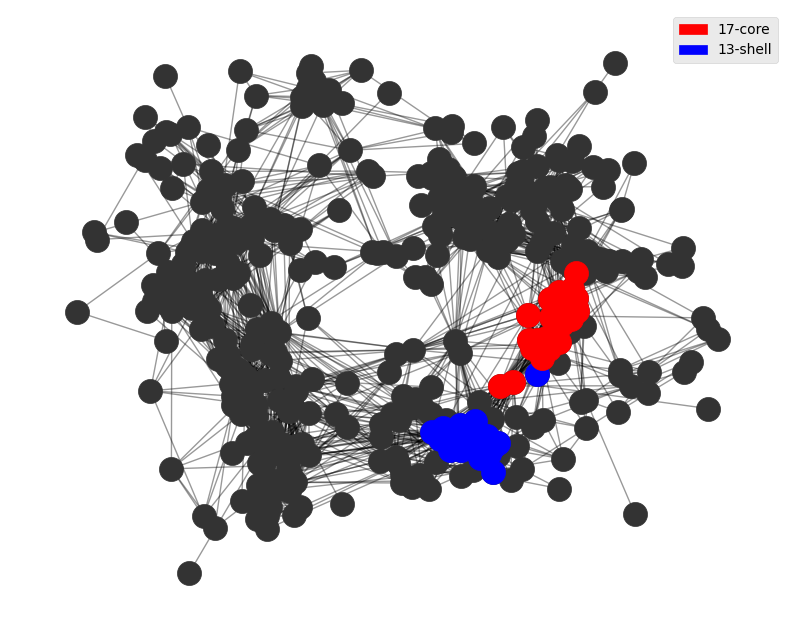

In [21]:
# the degree of network(g2)
fig, ax = plt.subplots(1,1,figsize=(10,8))

# Find k-cores
g2_core_13 = nx.k_shell(g2, 13)
g2_core_17 = nx.k_core(g2, 17)

# layout position
pos = nx.spring_layout(g2,seed=123456789,k=0.3)

# draw edges
nx.draw_networkx_edges(g2,
                       pos=pos,
                       alpha=0.4, ax=ax)

# draw nodes
nodes = nx.draw_networkx_nodes(g2,
                 pos=pos,
                 node_color="#333333")

# draw nodes
nodes = nx.draw_networkx_nodes(g2_core_13,
                 pos=pos,
                 node_color="blue")

nodes = nx.draw_networkx_nodes(g2_core_17,
                 pos=pos,
                 node_color="red")

# static legend
red_patch = mpatches.Patch(color='red', label='17-core')
blue_patch = mpatches.Patch(color='blue', label='13-shell')
plt.legend(handles=[red_patch,blue_patch])

plt.axis("off")
plt.savefig('k-core_sociopatterns.png', transparent=True,dpi=600)
plt.show()